In [48]:
%pip install tqdm
%pip install torch
%pip install numpy
%pip install scikit-learn
%pip install seaborn
%pip install matplotlib

import numpy as np
from tqdm import tqdm
import torch
from sklearn.utils import shuffle
from data_loader import get_data
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
# Match these to the names of the files you uploaded (without `.npy`)
class_names = ['bicycle', 'cactus', 'couch', 'diving board', 'flamingo', 'mushroom', 'ocean', 'octopus', 'shark', 'sweater']

file_paths = [f"./data/full_numpy_bitmap_{cls}.npy" for cls in class_names]

X_train, y_train, X_valid, y_valid, X_test, y_test = get_data(file_paths, 40000, 4000, 4000)


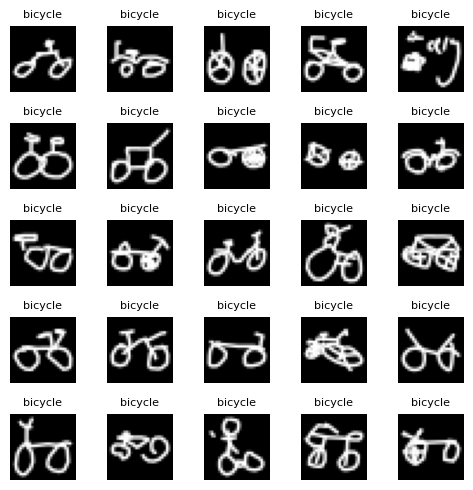

In [ ]:
def show_samples(X, y, classes, n=5):
    plt.figure(figsize=(n, n))
    for i in range(n * n):
        plt.subplot(n, n, i + 1)
        plt.imshow(X[0+i][0], cmap='gray')
        plt.title(classes[y[0+i]], fontsize=8)
        plt.axis('off')
    plt.tight_layout()
    plt.show()

show_samples(X_train, y_train, class_names, n=5)


In [ ]:
# Convert numpy arrays to torch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)
X_valid_tensor = torch.tensor(X_valid, dtype=torch.float32)
y_valid_tensor = torch.tensor(y_valid, dtype=torch.long)

print(X_test.shape)
print(y_test.shape)

# Create PyTorch datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
valid_dataset = TensorDataset(X_valid_tensor, y_valid_tensor)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)
valid_loader = DataLoader(valid_dataset, batch_size=64)

(40000, 1, 28, 28)
(40000,)


In [ ]:
class QuickDrawCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(QuickDrawCNN, self).__init__()

        # Convolutional layer 1: 1 input channel (grayscale), 16 output channels, 3x3 kernel
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)  # keeps size = 28x28
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)  # halves to 14x14

        # Convolutional layer 2: 16 input, 32 output
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)  # 14x14 → 14x14
        self.pool2 = nn.MaxPool2d(2, 2)  # 14x14 → 7x7

        # Fully connected layers
        self.fc1 = nn.Linear(32 * 7 * 7, 128)  # Flattened input → dense
        self.fc2 = nn.Linear(128, num_classes)  # Output layer

        self.dropout = nn.Dropout(0.25)

    def forward(self, x):
        x = self.pool1(F.relu(self.conv1(x)))  # (1,28,28) → (16,14,14)
        x = self.pool2(F.relu(self.conv2(x)))  # (16,14,14) → (32,7,7)
        x = x.view(-1, 32 * 7 * 7)  # Flatten for dense layer
        x = self.dropout(F.relu(self.fc1(x)))  # Dense with dropout
        x = self.fc2(x)  # No activation; will use CrossEntropyLoss
        return x

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = QuickDrawCNN(num_classes=10).to(device)
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [ ]:
def train_with_validation(model, train_loader, valid_loader, optimizer, criterion, device, epochs=5, save_best=False):
    model.to(device)
    best_val_acc = 0.0

    # Track history for plotting
    train_losses = []
    val_losses = []
    val_accuracies = []

    for epoch in range(epochs):
        # ----- TRAIN -----
        model.train()
        total_loss = 0
        train_loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)

        for X_batch, y_batch in train_loop:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            output = model(X_batch)
            loss = criterion(output, y_batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            train_loop.set_postfix(loss=loss.item())

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # ----- VALIDATE -----
        model.eval()
        valid_loss = 0
        correct = 0
        total = 0
        val_loop = tqdm(valid_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False)

        with torch.no_grad():
            for X_val, y_val in val_loop:
                X_val, y_val = X_val.to(device), y_val.to(device)
                output = model(X_val)
                loss = criterion(output, y_val)
                valid_loss += loss.item()

                preds = output.argmax(dim=1)
                correct += (preds == y_val).sum().item()
                total += y_val.size(0)

                val_loop.set_postfix(loss=loss.item())

        avg_valid_loss = valid_loss / len(valid_loader)
        val_accuracy = correct / total

        val_losses.append(avg_valid_loss)
        val_accuracies.append(val_accuracy)

        print(f"\nEpoch {epoch+1}/{epochs} | "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_valid_loss:.4f} | "
              f"Val Acc: {val_accuracy:.2%}")

        # Save best model if requested
        if save_best and val_accuracy > best_val_acc:
            best_val_acc = val_accuracy
            torch.save(model.state_dict(), 'best_model.pth')
            print("model saved!")

    print("✅ Training complete.")
    return train_losses, val_losses, val_accuracies

train_losses, val_losses, val_accuracies = train_with_validation(model, train_loader, valid_loader, optimizer, criterion, device, epochs=5, save_best=False)


Epoch 1/5 | Train Loss: 0.3352 | Val Loss: 0.2192 | Val Acc: 93.45%



Epoch 2/5 | Train Loss: 0.2236 | Val Loss: 0.2026 | Val Acc: 93.94%



Epoch 3/5 | Train Loss: 0.1970 | Val Loss: 0.1819 | Val Acc: 94.56%



Epoch 4/5 | Train Loss: 0.1806 | Val Loss: 0.1751 | Val Acc: 94.71%



Epoch 5/5 | Train Loss: 0.1706 | Val Loss: 0.1702 | Val Acc: 94.94%
✅ Training complete.


In [ ]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

# Convert to numpy arrays
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
print(classification_report(all_labels, all_preds, target_names=class_names, digits=4))

              precision    recall  f1-score   support

     bicycle     0.9768    0.9800    0.9784      4000
      cactus     0.9432    0.9597    0.9514      4000
       couch     0.9732    0.9547    0.9639      4000
diving board     0.8779    0.8790    0.8785      4000
    flamingo     0.9454    0.9520    0.9487      4000
    mushroom     0.9825    0.9523    0.9671      4000
       ocean     0.9202    0.9513    0.9355      4000
     octopus     0.9672    0.9660    0.9666      4000
       shark     0.9532    0.9530    0.9531      4000
     sweater     0.9714    0.9603    0.9658      4000

    accuracy                         0.9508     40000
   macro avg     0.9511    0.9508    0.9509     40000
weighted avg     0.9511    0.9508    0.9509     40000



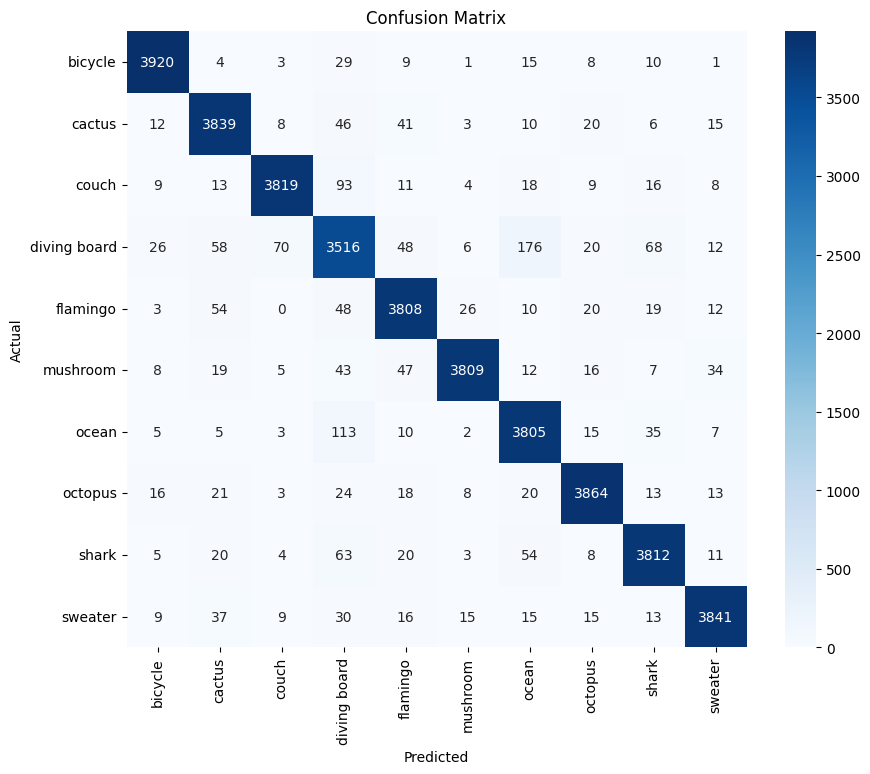

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

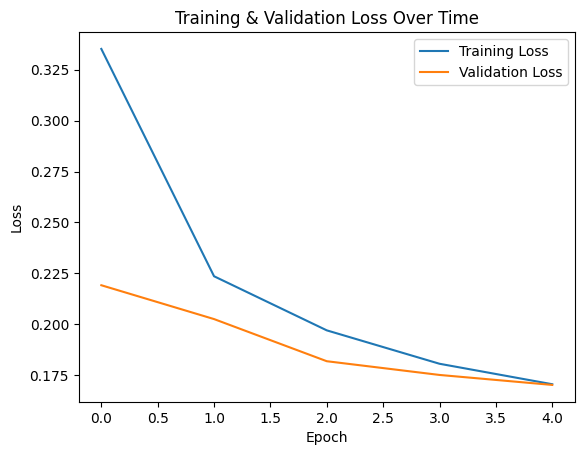

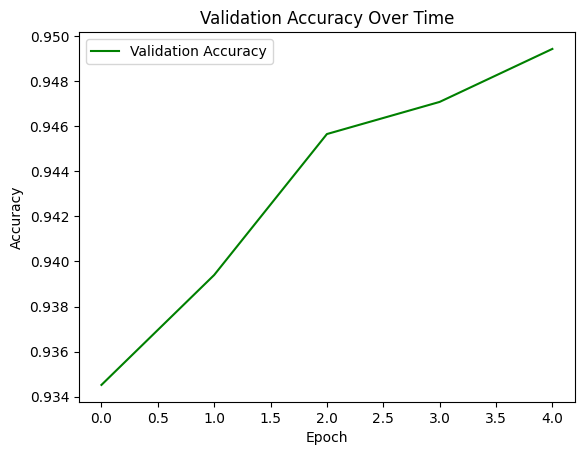

In [ ]:
epochs_range = range(len(train_losses))

plt.plot(epochs_range, train_losses, label="Training Loss")
plt.plot(epochs_range, val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss Over Time")
plt.legend()
plt.show()

plt.plot(epochs_range, val_accuracies, label="Validation Accuracy", color='green')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy Over Time")
plt.legend()
plt.show()


In [ ]:
def compute_top_k_accuracy(model, loader, k=3):
    correct = 0
    total = 0

    model.eval()
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            topk_preds = torch.topk(outputs, k, dim=1).indices
            correct += sum([y_batch[i] in topk_preds[i] for i in range(len(y_batch))])
            total += y_batch.size(0)

    return correct / total

top3_acc = compute_top_k_accuracy(model, test_loader, k=3)
print(f"Top-3 Accuracy: {top3_acc:.2%}")


Top-3 Accuracy: 98.54%
